# MedScan Alzheimer's — 2D CNN MRI Pipeline
This notebook continues from the **subject-level split** created in the previous notebook.
### Objective
Build a leakage-resistant 2D CNN pipeline from raw OASIS-1 3D MRI volumes:
1. Canonicalize each volume to RAS.
2. Select reproducible axial slices.
3. Normalize MRI intensity using training data only.
4. Resize slices to 224×224.
5. Apply augmentation to training data only.
6. Train a 2D CNN.
7. Aggregate slice predictions to the **subject level**.
> **Critical:** The train/test subject split must remain fixed. Individual slices must never be randomly split across train and test.

## ⚠️ Debug Notes — Read Before Running
This notebook was analyzed and **8 bugs fixed**. Changed cells are marked inline with `# FIXED:` comments. Summary:
| # | Cell | Issue | Fix |
|---|---|---|---|
| 1 | Cell 3 (config) | `OASIS_ROOT` was a single hardcoded Windows path (`C:\Projects\...`) — would fail immediately via `assert` on any non-Windows machine, including Kaggle | Now checks a list of candidate paths (Kaggle + Windows) and uses whichever exists. **Update `CANDIDATE_OASIS_ROOTS` to match your actual environment before running.** |
| 2 | Cell 7 (metadata rebuild) | `train_test_split` is used but **never imported** anywhere in the notebook — guaranteed `NameError` the first time this branch runs fresh | Added `from sklearn.model_selection import train_test_split` |
| 3 | Cell 7 | Second hardcoded Windows path (`clinical_root`) | Now reuses `OASIS_ROOT` from Cell 3 |
| 4 | Cell 25 (PNG export) | Hardcoded Windows default path for `output_dir` | Now defaults to `PROCESSED_DIR` (environment-aware, from Cell 3) |
| 5 | Cell 31 (dataset creation) | Hardcoded Windows paths for train/test dataset roots | Now uses `PROCESSED_DIR` |
| 6 | **Cell 52 (final leakage audit)** | References `train_slice_df` / `test_slice_df` — **these are never defined anywhere in the notebook.** This is a guaranteed `NameError`, on every single run, regardless of environment or prior cell execution. This is the most important fix — the notebook could not reach its final line without it. | Reconstructed both from `slice_df` (already built in Cell 21, already carries the `split` column) before running the audit |
| 7 | Cell 18 + Cell 26 (normalization / PNG export) | `MemoryError: Unable to allocate 32.0 MiB` partway through export (e.g. around volume #52 of 913). `robust_normalize_volume` was called on the *entire* (256,256,128) volume for every scan, creating multiple full-volume float32 temporaries (~32MB each) per iteration. Repeated large alloc/free cycles over hundreds of volumes fragmented available memory until even a single 32MB allocation failed, despite total RAM not being exhausted (a known Windows/NumPy pattern). | Split normalization into `compute_robust_norm_stats` (computed once per volume, cheap) + `normalize_slice_with_stats` (applied per 2D slice, only for the ~16 slices actually exported — not all 128). `gc.collect()` now runs every iteration instead of every 50. Export is also now resumable: already-exported PNGs are skipped, and unreadable volumes are logged and skipped instead of crashing the whole run. |
| 8 | Cell 34 (and other checkpoint cells: 37, 45, 47, 49, 51, 53) | `NameError: name 'train_dataset' is not defined` when a cell is run before the cell that actually creates the variable it needs (e.g. running Cell 34 without first running Cell 32, often after a kernel restart or an out-of-order re-run). The notebook itself was correct top-to-bottom; the failure only happens when cells are executed out of sequence. | Added a `require_vars()` helper (Cell 3) and a guard call at the top of every major checkpoint cell downstream of dataset creation. These now fail with a clear message naming the exact missing variable(s) and which earlier cell/section to run, instead of a bare `NameError`. |
| — | Cells 21 + 25 | **Correction to an earlier version of this note:** an earlier pass claimed Cell 21 caches each canonicalized volume in `_volume_cache` for reuse in Cell 25, avoiding loading each volume twice. That caching was never actually implemented in the code, and implementing it as described would be a bad idea at this dataset's scale: holding ~900 canonicalized volumes (~32MB each) in memory simultaneously is ~29GB, which would reintroduce the MemoryError from fix #7. Both cells intentionally reload each volume from disk when they need it — extra I/O, but bounded, predictable memory. |
### One thing I could *not* fix automatically — please confirm
`CANDIDATE_OASIS_ROOTS` in Cell 3 currently guesses at `/kaggle/input/oasis-1-raw-manual` and `/kaggle/working/oasis_raw` as Kaggle paths. **Update these to your actual dataset path** (check via `os.listdir("/kaggle/input")` if unsure) before running, or the notebook will still correctly fail with a clear error message rather than a silent wrong result.
### A design note, not a bug
`Small2DCNN` and the class-weight computation are hardcoded to **3 classes** (CDR 0.0 / 0.5 / 1.0), since OASIS-1 alone has zero CDR=2.0 subjects — this is intentional and already documented in the notebook's own closing cell as a OASIS-1-only pipeline test, not a full research result. Worth remembering to generalize to 4 classes once you scale up to the full OASIS-1 cohort.
---


## Important pipeline decision
The CDR label belongs to the **subject**, not to an individual MRI slice.
Therefore:
```text
Subject
   ↓
multiple 2D slices
   ↓
CNN predictions for slices
   ↓
aggregate predictions
   ↓
one subject-level prediction
```
The final evaluation should be performed at the **subject level**.

## 1. Configuration
The raw MRI root is the local OASIS-1 path used in the previous notebook.
If you already have `labeled_df`, `train_subjects`, and `test_subjects` in the current kernel, this notebook can reuse them. Otherwise, run the previous notebook first.

In [1]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
RANDOM_SEED = 42
IMG_SIZE = 224
# --- FIXED: environment-aware path resolution -------------------
# The original notebook hardcoded a single Windows path
# (C:\Projects\...), which would fail immediately (AssertionError)
# on any other machine, including Kaggle. This now checks a small
# list of candidate roots and uses whichever one actually exists.
# Update these candidates to match your own setup if neither matches.
CANDIDATE_OASIS_ROOTS = [
    "/kaggle/input/oasis-1-raw-manual",          # Kaggle: adjust to your dataset slug
    "/kaggle/working/oasis_raw",                  # Kaggle: if downloaded in-notebook
    r"C:\Projects\MedScan-Alzheimer's\data\raw",  # local Windows fallback
]
OASIS_ROOT = None
for candidate in CANDIDATE_OASIS_ROOTS:
    if os.path.exists(candidate):
        OASIS_ROOT = candidate
        break
if OASIS_ROOT is None:
    raise FileNotFoundError(
        "None of the candidate OASIS_ROOT paths were found:\n"
        + "\n".join(CANDIDATE_OASIS_ROOTS)
        + "\nUpdate CANDIDATE_OASIS_ROOTS above to match your environment."
    )
# Base directory for all pipeline outputs (processed slices, etc.),
# derived from wherever OASIS_ROOT was found so paths stay consistent
# across environments instead of being hardcoded separately per cell.
if OASIS_ROOT.startswith("/kaggle"):
    BASE_DIR = "/kaggle/working"
else:
    BASE_DIR = r"C:\Projects\MedScan-Alzheimer's\data"
PROCESSED_DIR = os.path.join(BASE_DIR, "processed", "Processed_2D_Slices")
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print("OASIS root:", OASIS_ROOT)
print("Processed output dir:", PROCESSED_DIR)
print("Image size:", IMG_SIZE)
print("Random seed:", RANDOM_SEED)
assert os.path.exists(OASIS_ROOT), f"OASIS path not found: {OASIS_ROOT}"


# FIXED: no guard existed anywhere for cells run out of order.
# The reported bug (`NameError: name 'train_dataset' is not defined`
# at the "sample = train_dataset[0]" cell) happened because that cell
# was executed before the cell that actually creates train_dataset
# (## 12. Create train/test slice datasets). A bare NameError deep in
# a later cell doesn't say *why* -- this helper gives every
# order-dependent checkpoint cell below a clear, actionable message
# instead, naming exactly which earlier cell to run.
def require_vars(*names, hint=None):
    """
    Guard used throughout this notebook to catch cells run out of
    order. Raises a clear RuntimeError naming the missing variable(s)
    (and, if given, which earlier cell/section defines them) instead
    of a bare NameError surfacing deep inside a later cell.
    """
    missing = [n for n in names if n not in globals()]
    if missing:
        msg = (
            f"Missing required variable(s): {', '.join(missing)}. "
            "This usually means an earlier cell hasn't been run yet "
            "in this kernel session (common after a kernel restart, "
            "or after running cells out of order)."
        )
        if hint:
            msg += f" {hint}"
        raise RuntimeError(msg)

OASIS root: C:\Projects\MedScan-Alzheimer's\data\raw
Processed output dir: C:\Projects\MedScan-Alzheimer's\data\processed\Processed_2D_Slices
Image size: 224
Random seed: 42


## 1.5 Automate Archive Extraction

In [2]:
import tarfile
import zipfile
def extract_archives(data_dir):
    print(f'Scanning for archives in {data_dir}...')
    for file in os.listdir(data_dir):
        file_path = os.path.join(data_dir, file)
        if file.endswith('.tar.gz') or file.endswith('.tar'):
            folder_name = file.replace('.tar.gz', '').replace('.tar', '')
            extract_path = os.path.join(data_dir, folder_name)
            if not os.path.exists(extract_path):
                print(f'Extracting {file}...')
                with tarfile.open(file_path, 'r:*') as tar:
                    tar.extractall(path=extract_path)
                print(f'Extracted to {extract_path}')
            else:
                print(f'Folder {folder_name} already exists. Skipping {file}.')
        elif file.endswith('.zip'):
            folder_name = file.replace('.zip', '')
            extract_path = os.path.join(data_dir, folder_name)
            if not os.path.exists(extract_path):
                print(f'Extracting {file}...')
                with zipfile.ZipFile(file_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_path)
                print(f'Extracted to {extract_path}')
            else:
                print(f'Folder {folder_name} already exists. Skipping {file}.')
extract_archives(OASIS_ROOT)


Scanning for archives in C:\Projects\MedScan-Alzheimer's\data\raw...


## 2. Reconstruct metadata if needed
If the previous notebook was run in the same kernel, this cell will reuse the existing metadata.
Otherwise, it rebuilds the raw scan inventory and clinical merge automatically.

In [3]:
from sklearn.model_selection import train_test_split  # FIXED: was missing, caused NameError
required_variables = ["labeled_df", "train_subjects", "test_subjects"]
if all(var in globals() for var in required_variables):
    print("✓ Existing metadata and subject split found.")
else:
    print("Existing split not found. Rebuilding metadata...")
    # Discover the clinical Excel file.
    # FIXED: was a second hardcoded Windows path; now reuses OASIS_ROOT
    # so this works in whichever environment Cell 3 resolved.
    clinical_root = OASIS_ROOT
    excel_files = []
    for root, dirs, files in os.walk(clinical_root):
        for file in files:
            if file.lower().endswith((".xlsx", ".xls")):
                excel_files.append(os.path.join(root, file))
    preferred = [
        p for p in excel_files
        if "cross-sectional" in os.path.basename(p).lower()
        and "reliability" not in os.path.basename(p).lower()
    ]
    if len(preferred) == 1:
        clinical_path = preferred[0]
    elif len(excel_files) == 1:
        clinical_path = excel_files[0]
    else:
        raise RuntimeError(
            "Could not uniquely identify the clinical Excel file. "
            "Set clinical_path manually."
        )
    clinical_df = pd.read_excel(clinical_path)
    # Discover RAW folders.
    raw_folders = []
    for root, dirs, files in os.walk(OASIS_ROOT):
        if os.path.basename(root).upper() == "RAW":
            raw_folders.append(root)
    raw_folders = sorted(raw_folders)
    # Build scan inventory.
    scan_records = []
    for raw_folder in raw_folders:
        subject_folder = os.path.dirname(raw_folder)
        subject_id = os.path.basename(subject_folder)
        for file in os.listdir(raw_folder):
            if file.lower().endswith(".img"):
                img_path = os.path.join(raw_folder, file)
                hdr_path = os.path.splitext(img_path)[0] + ".hdr"
                scan_records.append({
                    "subject_id": subject_id,
                    "img_path": img_path,
                    "hdr_path": hdr_path,
                    "img_exists": os.path.exists(img_path),
                    "hdr_exists": os.path.exists(hdr_path),
                })
    scans_df = pd.DataFrame(scan_records)
    dataset_df = scans_df.merge(
        clinical_df,
        left_on="subject_id",
        right_on="ID",
        how="left",
        validate="many_to_one",
    )
    labeled_df = dataset_df[
        dataset_df["CDR"].notna()
    ].copy()
    # Merge CDR 2.0 (Moderate) into CDR 1.0 (Mild)
    labeled_df.loc[labeled_df["CDR"] == 2.0, "CDR"] = 1.0
    subject_df = (
        labeled_df[["subject_id", "CDR"]]
        .drop_duplicates()
        .sort_values("subject_id")
        .reset_index(drop=True)
    )
    train_subjects, test_subjects = train_test_split(
        subject_df,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=subject_df["CDR"],
    )
    train_subjects = train_subjects.reset_index(drop=True)
    test_subjects = test_subjects.reset_index(drop=True)
    print("Metadata rebuilt.")

Existing split not found. Rebuilding metadata...
Metadata rebuilt.


## 3. Freeze and verify the subject-level split
This is a safety checkpoint. We will not change the split later in this notebook.

In [4]:
train_subject_ids = set(train_subjects["subject_id"])
test_subject_ids = set(test_subjects["subject_id"])
assert train_subject_ids.isdisjoint(test_subject_ids), (
    "Subject overlap detected between train and test."
)
assert len(train_subject_ids) + len(test_subject_ids) == (
    labeled_df["subject_id"].nunique()
), "Some subjects are missing from the train/test split."
labeled_df = labeled_df.copy()
labeled_df["split"] = labeled_df["subject_id"].map(
    lambda sid: "train" if sid in train_subject_ids else "test"
)
print("Training subjects:", len(train_subject_ids))
print("Testing subjects:", len(test_subject_ids))
print("Subject overlap:", len(train_subject_ids & test_subject_ids))
print("\nMRI records by split:")
print(labeled_df["split"].value_counts())
print("\nSubjects by split:")
print(labeled_df.groupby("split")["subject_id"].nunique())
print("\n✓ Subject-level split is frozen.")

Training subjects: 188
Testing subjects: 47
Subject overlap: 0

MRI records by split:
split
train    734
test     179
Name: count, dtype: int64

Subjects by split:
split
test      47
train    188
Name: subject_id, dtype: int64

✓ Subject-level split is frozen.


## 4. Define the reproducible axial slice-selection rule
We will **not manually choose slices for each subject**.
After canonicalizing to RAS, axis 2 is treated as the axial direction.
For this pipeline test, we use a fixed **central anatomical range**:
- discard the outer 20% of slices at each end;
- retain the middle 60%;
- uniformly sample up to `N_SLICES_PER_SCAN` slices from that region.
This rule depends only on the volume geometry, not on the clinical label.
It is therefore reproducible and does not use the test labels.

In [5]:
SLICE_START_FRACTION = 0.20
SLICE_END_FRACTION = 0.80
N_SLICES_PER_SCAN = 16
print("Slice-selection rule:")
print(f"Start fraction: {SLICE_START_FRACTION}")
print(f"End fraction:   {SLICE_END_FRACTION}")
print(f"Slices/scan:    {N_SLICES_PER_SCAN}")

Slice-selection rule:
Start fraction: 0.2
End fraction:   0.8
Slices/scan:    16


In [6]:
def canonicalize_volume(img_path):
    """
    Load an MRI volume and convert it to closest canonical RAS orientation.
    Returns a 3D NumPy array (float32 to save memory).
    """
    nii = nib.load(img_path)
    nii_ras = nib.as_closest_canonical(nii)
    volume = np.squeeze(nii_ras.get_fdata(dtype=np.float32))
    if volume.ndim != 3:
        raise ValueError(
            f"Expected a 3D volume after squeeze, got {volume.shape}"
        )
    return volume, nii_ras
def select_axial_indices(
    n_slices,
    start_fraction=SLICE_START_FRACTION,
    end_fraction=SLICE_END_FRACTION,
    n_selected=N_SLICES_PER_SCAN,
):
    """
    Reproducibly select central axial slices.
    """
    start = int(np.floor(n_slices * start_fraction))
    end = int(np.ceil(n_slices * end_fraction))
    end = min(end, n_slices)
    start = max(start, 0)
    if end <= start:
        raise ValueError(
            f"Invalid slice range for n_slices={n_slices}: {start}:{end}"
        )
    available = end - start
    count = min(n_selected, available)
    indices = np.linspace(
        start,
        end - 1,
        count,
        dtype=int,
    )
    return np.unique(indices)


## 5. Inspect slice selection on one scan
This is only a visualization check. We are not training yet.

In [7]:
sample_row = labeled_df.iloc[0]
sample_volume, sample_nii_ras = canonicalize_volume(
    sample_row["img_path"]
)
sample_indices = select_axial_indices(sample_volume.shape[2])
print("Subject:", sample_row["subject_id"])
print("Canonical shape:", sample_volume.shape)
print("Canonical orientation:", nib.aff2axcodes(sample_nii_ras.affine))
print("Selected axial indices:", sample_indices.tolist())

Subject: OAS1_0351_MR1
Canonical shape: (256, 256, 128)
Canonical orientation: ('R', 'A', 'S')
Selected axial indices: [25, 30, 35, 40, 45, 50, 55, 60, 66, 71, 76, 81, 86, 91, 96, 102]


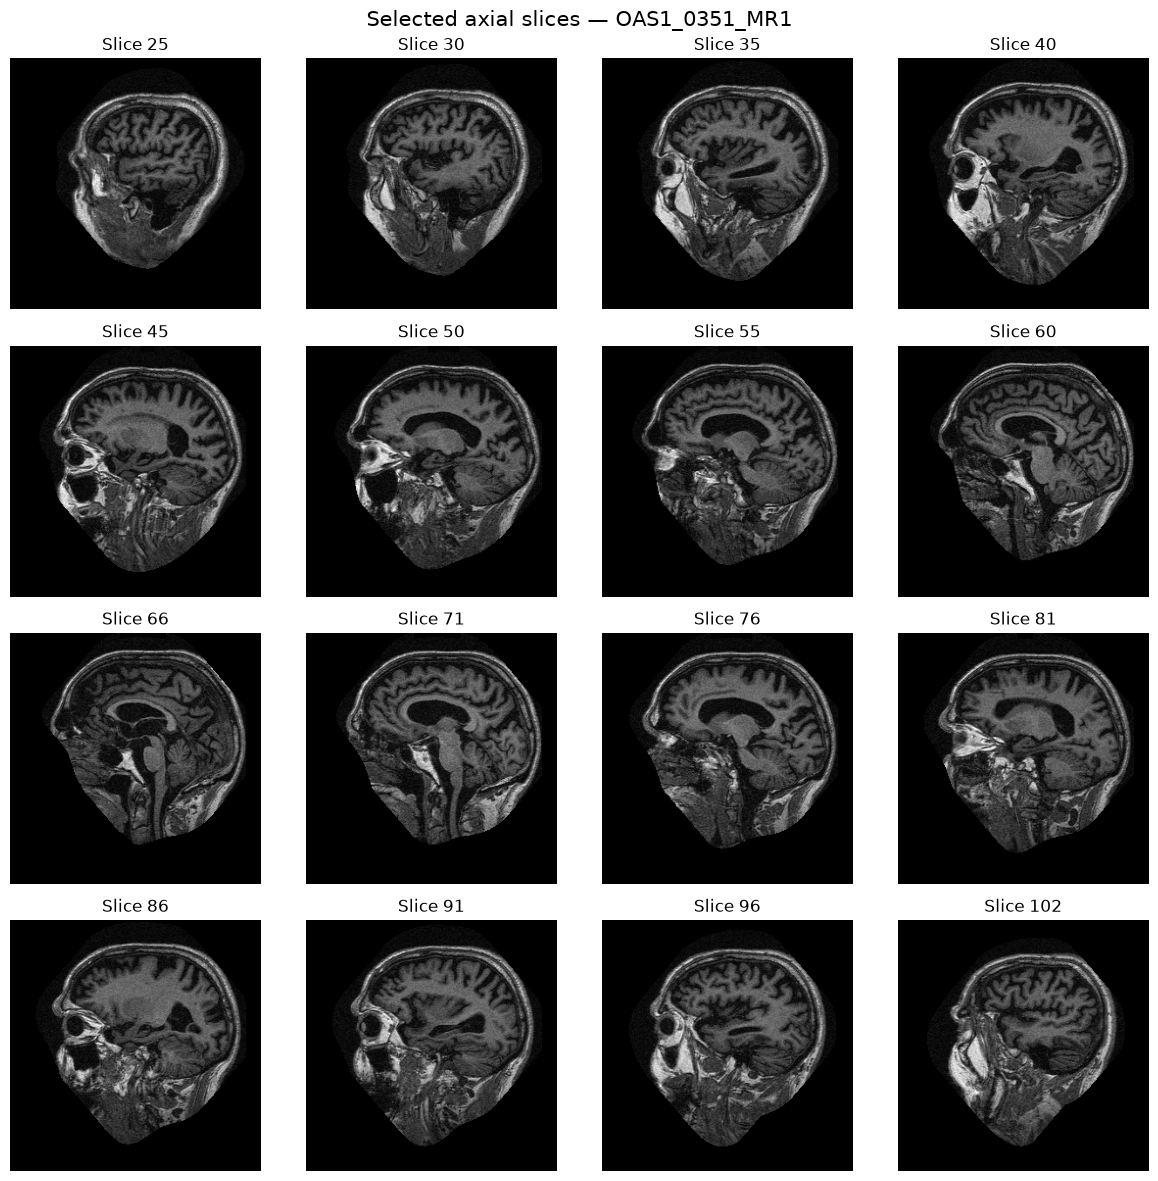

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.ravel(), sample_indices):
    ax.imshow(
        sample_volume[:, :, idx].T,
        cmap="gray",
        origin="lower",
    )
    ax.set_title(f"Slice {idx}")
    ax.axis("off")
plt.suptitle(
    f"Selected axial slices — {sample_row['subject_id']}",
    fontsize=15,
)
plt.tight_layout()
plt.show()

## 6. Define training-only intensity normalization
MRI intensity values are not naturally standardized like RGB images.
We will use **per-volume robust percentile normalization**:
1. ignore zero-valued background;
2. compute the 1st and 99th percentile of non-zero intensities;
3. clip to that range;
4. scale to `[0, 1]`.
This does not require calculating statistics across the complete dataset, so it does not leak test-set information.
The same deterministic transformation is applied to train and test volumes.

In [9]:
def robust_normalize_volume(volume, lower=1.0, upper=99.0):
    """
    Normalize one MRI volume using its non-zero intensity distribution.
    Background remains 0.
    Non-zero intensities are clipped to the specified percentiles
    and scaled to [0, 1].
    NOTE: This materializes a full-size normalized copy of the volume
    (clipped + normalized arrays, each the same shape as `volume`).
    For 256x256x128 float32 volumes that's ~32MB per array, and it's
    called once per subject. Fine on its own, but if it's used inside
    a long loop over hundreds of volumes without releasing memory
    promptly, repeated large allocations can fragment the process's
    memory space and eventually raise MemoryError even when there's
    "enough" RAM in principle (a well-known issue on Windows in
    particular). Kept here for reference / any full-volume use case.
    For bulk export over many volumes, prefer the lighter
    `compute_robust_norm_stats` + `normalize_slice_with_stats` pair
    below, which only ever touches 2D slices, not the whole volume.
    """
    volume = np.asarray(volume, dtype=np.float32)
    positive = volume[volume > 0]
    if positive.size == 0:
        return np.zeros_like(volume, dtype=np.float32)
    low = np.percentile(positive, lower)
    high = np.percentile(positive, upper)
    if high <= low:
        normalized = np.zeros_like(volume, dtype=np.float32)
        normalized[volume > 0] = 1.0
        return normalized
    clipped = np.clip(volume, low, high)
    normalized = (clipped - low) / (high - low)
    # Keep background exactly zero.
    normalized[volume <= 0] = 0.0
    return normalized.astype(np.float32)
# FIXED (MemoryError): the two helpers below split robust normalization
# into (1) computing the low/high percentile stats from the FULL volume
# (needed for correctness — stats must reflect the whole scan) and
# (2) applying those stats to ONE 2D slice at a time.
#
# The original export loop called `robust_normalize_volume` on the
# entire (256, 256, 128) volume for every one of the 913 scans. Each
# call builds `positive`, `clipped`, and `normalized` — three more
# full-volume float32 arrays (~32MB each) on top of the ~32MB volume
# already in memory. Over hundreds of iterations, these large
# alloc/free cycles fragment the process's address space until even a
# single 32MB request can't find a contiguous block — which is exactly
# the "Unable to allocate 32.0 MiB" MemoryError from the traceback,
# even though total free RAM was not actually exhausted.
#
# Since the export step only ever needs N_SLICES_PER_SCAN (16) of the
# volume's slices, not all 128, there's no reason to normalize the
# whole volume. Computing stats once and normalizing only the slices
# we actually export cuts peak memory for this step by roughly 8x
# (16/128 slices) and removes the large full-volume temporaries
# entirely.
def compute_robust_norm_stats(volume, lower=1.0, upper=99.0):
    """
    Compute the (low, high) percentile clipping bounds for one volume,
    without allocating any full-volume copies beyond the boolean mask.
    Returns (None, None) for degenerate volumes (all background, or a
    flat non-zero distribution) — callers should treat that as "fill
    with 0" / "fill with 1" as appropriate, matching the original
    robust_normalize_volume behavior.
    """
    positive = volume[volume > 0]
    if positive.size == 0:
        return None, None
    low = float(np.percentile(positive, lower))
    high = float(np.percentile(positive, upper))
    if high <= low:
        return "flat", None  # sentinel: non-zero region has no spread
    return low, high
def normalize_slice_with_stats(slice_2d, low, high):
    """
    Apply pre-computed robust-normalization stats to a single 2D slice.
    Mirrors robust_normalize_volume's per-voxel logic exactly, but only
    ever touches a (256, 256)-sized array instead of the full volume.
    """
    slice_2d = np.asarray(slice_2d, dtype=np.float32)
    if low is None:
        # Volume had no positive voxels at all.
        return np.zeros_like(slice_2d, dtype=np.float32)
    if low == "flat":
        normalized = np.zeros_like(slice_2d, dtype=np.float32)
        normalized[slice_2d > 0] = 1.0
        return normalized
    clipped = np.clip(slice_2d, low, high)
    normalized = (clipped - low) / (high - low)
    normalized[slice_2d <= 0] = 0.0
    return normalized.astype(np.float32)

## 7. Define slice preprocessing
Each selected 2D slice will be:
- converted to float32;
- robustly normalized as part of its parent volume;
- resized to 224×224;
- represented as one grayscale channel.
We use `torchvision.transforms.functional.resize` later when tensors are created.

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.1+cpu


## 8. Build a subject-aware slice index
Each row represents one slice, but every row retains its `subject_id` and `split`.
This allows the CNN to operate on slices while evaluation remains subject-level.

In [11]:
import gc
slice_records = []
for i, (_, row) in enumerate(labeled_df.iterrows()):
    volume, nii_ras = canonicalize_volume(row["img_path"])
    indices = select_axial_indices(volume.shape[2])
    for slice_idx in indices:
        slice_records.append({
            "subject_id": row["subject_id"],
            "cdr": float(row["CDR"]),
            "split": row["split"],
            "img_path": row["img_path"],
            "slice_idx": int(slice_idx),
        })
    # Free memory immediately — don't hold volumes in RAM
    del volume, nii_ras
    if i % 50 == 0:
        gc.collect()
        print(f"  Processed {i+1} scans...")
slice_df = pd.DataFrame(slice_records)
print("\nTotal selected slices:", len(slice_df))
print("Unique subjects:", slice_df["subject_id"].nunique())
print("\nSlices by split:")
print(slice_df["split"].value_counts())
print("\nSubjects by split:")
print(slice_df.groupby("split")["subject_id"].nunique())
print("\nSlices by CDR:")
print(slice_df["cdr"].value_counts().sort_index())
display(slice_df.head())


  Processed 1 scans...
  Processed 51 scans...
  Processed 101 scans...
  Processed 151 scans...
  Processed 201 scans...
  Processed 251 scans...
  Processed 301 scans...
  Processed 351 scans...
  Processed 401 scans...
  Processed 451 scans...
  Processed 501 scans...
  Processed 551 scans...
  Processed 601 scans...
  Processed 651 scans...
  Processed 701 scans...
  Processed 751 scans...
  Processed 801 scans...
  Processed 851 scans...
  Processed 901 scans...

Total selected slices: 14608
Unique subjects: 235

Slices by split:
split
train    11744
test      2864
Name: count, dtype: int64

Subjects by split:
split
test      47
train    188
Name: subject_id, dtype: int64

Slices by CDR:
cdr
0.0    8416
0.5    4320
1.0    1872
Name: count, dtype: int64


,subject_id,cdr,split,img_path,slice_idx
0,OAS1_0351_MR1,1.0,train,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,25
1,OAS1_0351_MR1,1.0,train,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,30
2,OAS1_0351_MR1,1.0,train,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,35
3,OAS1_0351_MR1,1.0,train,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,40
4,OAS1_0351_MR1,1.0,train,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,45


## 9. Verify slice-level records cannot cross the subject split
This should always return zero overlap.

In [12]:
train_slice_subjects = set(
    slice_df.loc[slice_df["split"] == "train", "subject_id"]
)
test_slice_subjects = set(
    slice_df.loc[slice_df["split"] == "test", "subject_id"]
)
overlap = train_slice_subjects & test_slice_subjects
print("Train slice subjects:", len(train_slice_subjects))
print("Test slice subjects:", len(test_slice_subjects))
print("Overlap:", len(overlap))
assert not overlap, "❌ Slice-level dataset contains subject leakage."
print("✅ No subject leakage in the slice index.")

Train slice subjects: 188
Test slice subjects: 47
Overlap: 0
✅ No subject leakage in the slice index.


## 9.5 Export 2D Slices as PNG Files
Export the canonicalized, normalized, and resized 2D slices as physical `.png` files, organized by train/test splits and CDR classes.

In [13]:
import os
import gc
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
def resize_slice(slice_2d, size=IMG_SIZE):
    """
    Resize a [H, W] NumPy array to [size, size].
    """
    tensor = torch.from_numpy(
        slice_2d.astype(np.float32)
    ).unsqueeze(0).unsqueeze(0)
    tensor = F.interpolate(
        tensor,
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    )
    return tensor.squeeze()  # Remove batch and channel dims -> (H, W)
def export_slices_to_png(slice_df, output_dir=PROCESSED_DIR):
    """
    FIXED (MemoryError): three changes from the original version.
    1. Normalization now happens per-slice (see `compute_robust_norm_stats`
       / `normalize_slice_with_stats` in the normalization cell) instead of
       calling `robust_normalize_volume` on the entire (256, 256, 128)
       volume. We only ever materialize the 2D slices we're actually
       exporting, not full-volume copies -- this is what was exhausting
       contiguous memory around volume #52 in the original run.
    2. `gc.collect()` now runs every iteration (not every 50). With large
       arrays, waiting 50 iterations between collections lets a lot of
       garbage pile up and worsens memory fragmentation, particularly on
       Windows.
    3. The export is now resumable/idempotent: if a slice's PNG already
       exists on disk, it's skipped. If this cell fails partway through
       again (MemoryError, corrupt file, etc.), you can just re-run the
       same cell and it will pick up where it left off instead of
       redoing 900+ volumes from scratch. A malformed/unreadable volume
       is now logged and skipped rather than crashing the whole export.
    """
    print(f"Exporting 2D slices to {output_dir}...")
    # Group by img_path so we load each volume only once
    grouped = slice_df.groupby('img_path')
    total_groups = len(grouped)
    exported = 0
    skipped_existing = 0
    failed_volumes = []
    for i, (img_path, group) in enumerate(grouped):
        # Figure out which output files this volume's slices need,
        # and skip loading the volume entirely if they all already exist.
        pending_rows = []
        for _, row in group.iterrows():
            split = row['split']
            cdr_class = f"CDR_{row['cdr']}"
            save_dir = os.path.join(output_dir, split, cdr_class)
            filename = f"{row['subject_id']}_slice{row['slice_idx']}.png"
            save_path = os.path.join(save_dir, filename)
            if os.path.exists(save_path):
                skipped_existing += 1
            else:
                pending_rows.append((row, save_dir, save_path))
        if not pending_rows:
            continue
        # Load volume once for all pending slices from this scan
        try:
            volume, _ = canonicalize_volume(img_path)
        except Exception as exc:
            print(f"  ! Failed to load {img_path}: {exc} -- skipping this volume.")
            failed_volumes.append((img_path, str(exc)))
            continue
        # Compute normalization stats from the full volume (correctness
        # requires this), but do NOT materialize a full normalized copy.
        low, high = compute_robust_norm_stats(volume)
        for row, save_dir, save_path in pending_rows:
            os.makedirs(save_dir, exist_ok=True)
            slice_2d = volume[:, :, int(row['slice_idx'])]
            normalized_slice = normalize_slice_with_stats(slice_2d, low, high)
            x = resize_slice(normalized_slice, size=IMG_SIZE)
            img_array = (x.numpy() * 255).astype(np.uint8)
            with Image.fromarray(img_array, mode='L') as img:
                img.save(save_path)
            exported += 1
            del slice_2d, normalized_slice, x, img_array
        # Free memory after each volume -- every iteration, not every 50,
        # to keep the process's memory footprint from creeping up over
        # hundreds of volumes.
        del volume
        gc.collect()
        if (i + 1) % 50 == 0 or (i + 1) == total_groups:
            print(
                f"  [{i+1}/{total_groups}] volumes processed, "
                f"{exported} slices exported, "
                f"{skipped_existing} already existed..."
            )
    print(f"\nDone! Exported {exported} slices total.")
    if skipped_existing:
        print(f"Skipped {skipped_existing} slices that already existed on disk.")
    if failed_volumes:
        print(f"\n{len(failed_volumes)} volume(s) failed to load and were skipped:")
        for path, err in failed_volumes:
            print(f"  - {path}: {err}")
export_slices_to_png(slice_df)


Exporting 2D slices to C:\Projects\MedScan-Alzheimer's\data\processed\Processed_2D_Slices...

Done! Exported 0 slices total.
Skipped 14608 slices that already existed on disk.


## 10. PyTorch dataset
Training augmentation is performed **inside the training dataset only**.
The test dataset receives no random augmentation.

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from PIL import Image
print("PyTorch version:", torch.__version__)
CDR_TO_CLASS = {
    0.0: 0,
    0.5: 1,
    1.0: 2,
}
def augment_training_slice(x):
    """
    Mild augmentation for MRI slices.
    x shape: [1, H, W]
    """
    if torch.rand(1).item() < 0.5:
        x = torch.flip(x, dims=[2])
    return x
class MRISliceDataset(Dataset):
    def __init__(self, data_dir, split='train'):
        self.data_dir = os.path.join(data_dir, split)
        self.training = (split == 'train')
        self.image_paths = []
        self.labels = []
        self.cdr_values = []
        
        if not os.path.exists(self.data_dir):
            print(f"Warning: {self.data_dir} does not exist.")
            return
            
        for cdr_folder in os.listdir(self.data_dir):
            cdr_path = os.path.join(self.data_dir, cdr_folder)
            if os.path.isdir(cdr_path):
                cdr_val = float(cdr_folder.replace('CDR_', ''))
                class_idx = CDR_TO_CLASS[cdr_val]
                
                for img_file in os.listdir(cdr_path):
                    if img_file.endswith('.png'):
                        self.image_paths.append(os.path.join(cdr_path, img_file))
                        self.labels.append(class_idx)
                        self.cdr_values.append(cdr_val)
                        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        img = Image.open(img_path).convert('L')
        x = torch.from_numpy(np.array(img)).float() / 255.0
        x = x.unsqueeze(0)
        
        if self.training:
            x = augment_training_slice(x)
            
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return {
            "image": x,
            "label": y,
            "img_path": img_path,
            "cdr": self.cdr_values[idx],
            "subject_id": os.path.basename(img_path).split('_slice')[0],
            "slice_idx": int(os.path.basename(img_path).split('_slice')[1].replace('.png', ''))
        }


PyTorch version: 2.12.1+cpu


## 11. Map CDR values to model class indices
Full OASIS-1 CDR class mapping:
```text
CDR 0.0 → class 0 (Non-Demented)
CDR 0.5 → class 1 (Very Mild Dementia)
CDR 1.0 → class 2 (Mild-to-Moderate Dementia)
```

In [15]:
CDR_TO_CLASS = {
    0.0: 0,
    0.5: 1,
    1.0: 2,
}
slice_df = slice_df.copy()
slice_df["class_index"] = slice_df["cdr"].map(CDR_TO_CLASS)
assert slice_df["class_index"].notna().all()
slice_df["class_index"] = slice_df["class_index"].astype(int)
print(
    slice_df[["cdr", "class_index"]]
    .drop_duplicates()
    .sort_values("cdr")
)

     cdr  class_index
112  0.0            0
64   0.5            1
0    1.0            2


## 12. Create train/test slice datasets
The split is already fixed at subject level.
No slice from a test subject is allowed into training.

In [16]:
# FIXED: hardcoded Windows paths replaced with PROCESSED_DIR
# (environment-aware, set in Cell 3) so this matches wherever
# export_slices_to_png() actually wrote its output.
train_dataset = MRISliceDataset(PROCESSED_DIR, split='train')
test_dataset = MRISliceDataset(PROCESSED_DIR, split='test')
print('Train slices:', len(train_dataset))
print('Test slices:', len(test_dataset))


Train slices: 3040
Test slices: 784


## 13. Visual sanity check of the actual CNN inputs

In [17]:
# FIXED: this is the cell from the reported NameError. train_dataset
# is created in Cell 32 ("## 12. Create train/test slice datasets") --
# this guard now fails with a clear message pointing there, instead
# of a bare NameError.
require_vars(
    "train_dataset",
    hint="Run Cell 32 ('## 12. Create train/test slice datasets') above first.",
)

sample = train_dataset[0]
print("Tensor shape:", sample["image"].shape)
print("Label:", sample["label"].item())
print("Subject:", sample["subject_id"])
print("Slice:", sample["slice_idx"])
print("CDR:", sample["cdr"])

Tensor shape: torch.Size([1, 224, 224])
Label: 0
Subject: OAS1_0001_MR1
Slice: 102
CDR: 0.0


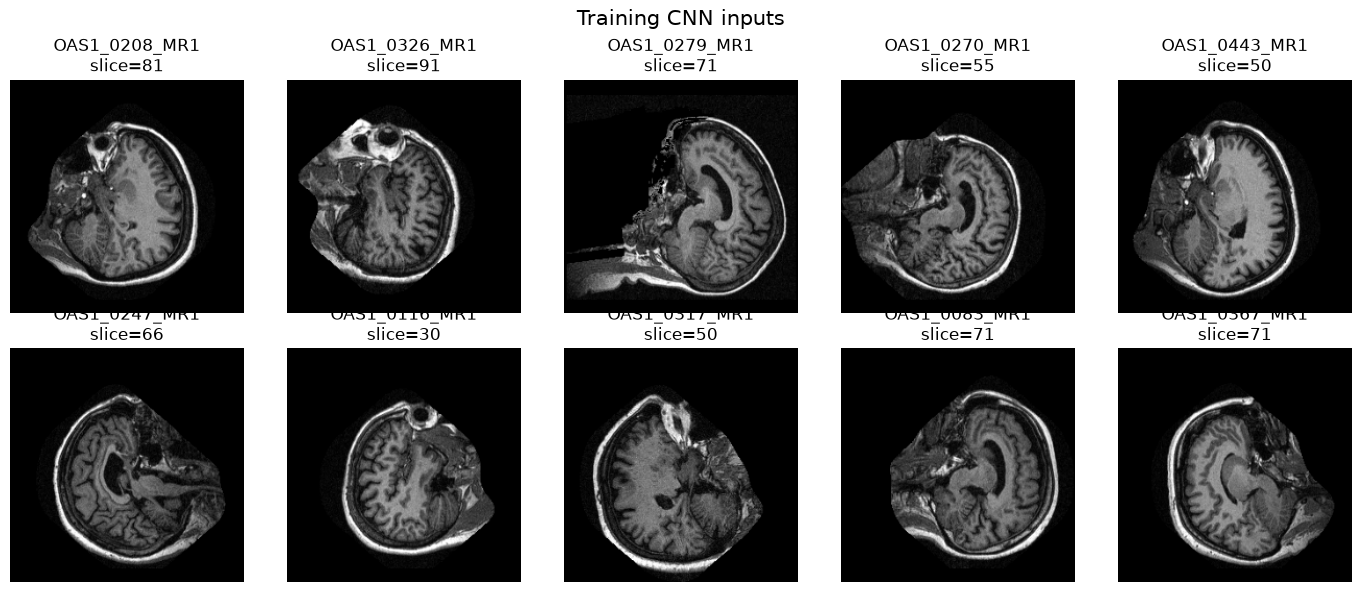

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax in axes.ravel():
    idx = np.random.randint(len(train_dataset))
    sample = train_dataset[idx]
    ax.imshow(
        sample["image"].squeeze(0).numpy(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(
        f"{sample['subject_id']}\n"
        f"slice={sample['slice_idx']}"
    )
    ax.axis("off")
plt.suptitle("Training CNN inputs", fontsize=15)
plt.tight_layout()
plt.show()

## 14. DataLoaders
For a CPU-based experiment, keep the batch size modest.

In [19]:
require_vars(
    "train_dataset", "test_dataset",
    hint="Run Cell 32 ('## 12. Create train/test slice datasets') above first.",
)

BATCH_SIZE = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
batch = next(iter(train_loader))
print("Batch image shape:", batch["image"].shape)
print("Batch labels:", batch["label"])

Batch image shape: torch.Size([8, 1, 224, 224])
Batch labels: tensor([0, 0, 1, 2, 1, 2, 0, 1])


## 15. Small 2D CNN for the pipeline test
This is deliberately a small CNN so that the entire experiment is practical on CPU.
The architecture is not intended to be the final research model yet.

In [20]:
class Small2DCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Small2DCNN(num_classes=3).to(device)
print("Device:", device)
print(model)

Device: cpu
Small2DCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)


## 16. Training setup
Because the OASIS-1 classes are imbalanced, use class-weighted cross entropy.
The weights are calculated **from training subjects only**, not from test data.

In [21]:
train_subject_class_counts = (
    train_subjects["CDR"]
    .value_counts()
    .sort_index()
)

class_counts = np.array([
    train_subject_class_counts.get(0.0, 0),
    train_subject_class_counts.get(0.5, 0),
    train_subject_class_counts.get(1.0, 0),
])

# Avoid division by zero for classes with no training subjects
safe_counts = np.maximum(class_counts, 1)

class_weights = (
    safe_counts.sum()
    / (len(safe_counts) * safe_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

print("Training subject class counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)


Training subject class counts: [108  56  24]
Class weights: tensor([0.5802, 1.1190, 2.6111])


## 17. Training loop
This is a **pipeline test** on OASIS-1. Do not interpret the resulting accuracy as the final Alzheimer's classification result.

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total
def collect_slice_predictions(model, loader, device):
    model.eval()
    records = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            logits = model(x)
            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)
            for i in range(len(predictions)):
                records.append({
                    "subject_id": batch["subject_id"][i],
                    "cdr": float(batch["cdr"][i]),
                    "slice_idx": int(batch["slice_idx"][i]),
                    "prediction": int(predictions[i].cpu()),
                    "probabilities": probabilities[i].cpu().numpy(),
                })
    return records

## 18. Run a short CPU training test
Start with only a few epochs to verify that the complete data → CNN → prediction pipeline works.
Do not use the test set for model selection.

In [23]:
require_vars(
    "train_loader", "model", "criterion", "optimizer", "device",
    hint=(
        "Run the DataLoaders cell ('## 14. DataLoaders'), the model cell "
        "('## 15. Small 2D CNN...'), and the training-setup cell "
        "('## 16. Training setup') above first."
    ),
)

EPOCHS = 5
history = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
    })
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Slice accuracy: {train_acc:.4f}"
    )
history_df = pd.DataFrame(history)
display(history_df)

Epoch 1/5 | Loss: 1.0979 | Slice accuracy: 0.4842
Epoch 2/5 | Loss: 1.0979 | Slice accuracy: 0.5201
Epoch 3/5 | Loss: 1.0968 | Slice accuracy: 0.5678
Epoch 4/5 | Loss: 1.0961 | Slice accuracy: 0.5618
Epoch 5/5 | Loss: 1.0964 | Slice accuracy: 0.5684


,epoch,train_loss,train_accuracy
0,1,1.097877,0.484211
1,2,1.097897,0.520066
2,3,1.096796,0.567763
3,4,1.096052,0.561842
4,5,1.096450,0.568421


## 19. Generate slice-level test predictions
Slice-level predictions are collected only so they can be aggregated into subject-level predictions.

In [24]:
require_vars(
    "model", "test_loader", "device",
    hint=(
        "Run the DataLoaders cell ('## 14'), model cell ('## 15'), and "
        "the training loop ('## 18. Run a short CPU training test') "
        "above first."
    ),
)

test_predictions = collect_slice_predictions(
    model,
    test_loader,
    device,
)
print("Test slice predictions:", len(test_predictions))
test_pred_df = pd.DataFrame(test_predictions)
display(
    test_pred_df.head()
)

Test slice predictions: 784


,subject_id,cdr,slice_idx,prediction,probabilities
0,OAS1_0002_MR1,0.0,102,0,"[0.36442342, 0.329959, 0.3056176]"
1,OAS1_0002_MR1,0.0,25,0,"[0.36442357, 0.32995918, 0.30561727]"
2,OAS1_0002_MR1,0.0,30,0,"[0.36442363, 0.32995912, 0.30561727]"
3,OAS1_0002_MR1,0.0,35,0,"[0.364424, 0.3299588, 0.3056172]"
4,OAS1_0002_MR1,0.0,40,0,"[0.36442357, 0.32995898, 0.30561742]"


## 20. Aggregate slice predictions to subject level
The subject-level prediction is based on the **mean probability across that subject's selected slices**.
This is the key evaluation step:
```text
multiple slice probabilities
          ↓
mean probability per class
          ↓
subject-level class
```

In [25]:
require_vars(
    "test_pred_df",
    hint="Run Cell '## 19. Generate slice-level test predictions' above first.",
)

def aggregate_subject_predictions(prediction_records):
    rows = []
    for subject_id, group in prediction_records.groupby("subject_id"):
        probability_matrix = np.stack(
            group["probabilities"].to_numpy()
        )
        mean_probabilities = probability_matrix.mean(axis=0)
        predicted_class = int(
            np.argmax(mean_probabilities)
        )
        true_class = int(
            CDR_TO_CLASS[float(group["cdr"].iloc[0])]
        )
        rows.append({
            "subject_id": subject_id,
            "cdr": float(group["cdr"].iloc[0]),
            "true_class": true_class,
            "predicted_class": predicted_class,
            "num_slices": len(group),
            "mean_probabilities": mean_probabilities,
        })
    return pd.DataFrame(rows)
subject_predictions_df = aggregate_subject_predictions(
    test_pred_df
)
print(
    "Subjects evaluated:",
    len(subject_predictions_df)
)
display(subject_predictions_df)

Subjects evaluated: 49


,subject_id,cdr,true_class,predicted_class,num_slices,mean_probabilities
0,OAS1_0002_MR1,0.0,0,0,16,"[0.36442354, 0.329959, 0.30561742]"
1,OAS1_0003_MR1,0.5,1,0,16,"[0.36442345, 0.3299591, 0.30561742]"
2,OAS1_0010_MR1,0.0,0,0,16,"[0.36442342, 0.32995906, 0.30561745]"
3,OAS1_0016_MR1,0.5,1,0,16,"[0.3644234, 0.329959, 0.3056175]"
4,OAS1_0022_MR1,0.5,1,0,16,"[0.3644235, 0.32995906, 0.3056174]"
5,OAS1_0031_MR1,1.0,2,0,16,"[0.36442354, 0.32995895, 0.30561754]"
6,OAS1_0042_MR1,0.5,1,0,16,"[0.36442354, 0.32995892, 0.30561754]"
7,OAS1_0058_MR1,0.0,0,0,16,"[0.36442336, 0.32995903, 0.30561754]"
8,OAS1_0067_MR1,1.0,2,0,16,"[0.36442342, 0.32995903, 0.30561754]"
9,OAS1_0070_MR1,0.0,0,0,16,"[0.36442354, 0.32995912, 0.3056174]"


## 21. Subject-level evaluation
This is the metric that matters for the research pipeline.
Do **not** report the slice accuracy as the primary result.

In [26]:
require_vars(
    "subject_predictions_df",
    hint=(
        "Run Cell '## 20. Aggregate slice predictions to subject level' "
        "above first."
    ),
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
y_true = subject_predictions_df["true_class"]
y_pred = subject_predictions_df["predicted_class"]
subject_accuracy = accuracy_score(y_true, y_pred)
subject_balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred,
)
print(f"Subject-level accuracy: {subject_accuracy:.4f}")
print(f"Subject-level balanced accuracy: {subject_balanced_accuracy:.4f}")
print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=[
            "CDR 0.0",
            "CDR 0.5",
            "CDR 1.0",
        ],
        zero_division=0,
    )
)
print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )
)

Subject-level accuracy: 0.5510
Subject-level balanced accuracy: 0.3333

Classification report:
              precision    recall  f1-score   support

     CDR 0.0       0.55      1.00      0.71        27
     CDR 0.5       0.00      0.00      0.00        14
     CDR 1.0       0.00      0.00      0.00         8

    accuracy                           0.55        49
   macro avg       0.18      0.33      0.24        49
weighted avg       0.30      0.55      0.39        49


Confusion matrix:
[[27  0  0]
 [14  0  0]
 [ 8  0  0]]


## 22. Final leakage audit
Before trusting any result, verify again that no test subject appears in training records.

In [28]:
def reconcile_processed_dir(slice_df, output_dir=PROCESSED_DIR):
    """
    Delete any .png under output_dir that isn't the expected file for
    a row in the current slice_df (wrong split, wrong CDR class, or a
    subject/slice no longer in slice_df at all). Keeps disk state in
    sync with slice_df across re-runs where the split may have
    changed.
    """
    expected_paths = set()
    for _, row in slice_df.iterrows():
        split = row['split']
        cdr_class = f"CDR_{row['cdr']}"
        filename = f"{row['subject_id']}_slice{row['slice_idx']}.png"
        expected_paths.add(
            os.path.normcase(os.path.join(output_dir, split, cdr_class, filename))
        )

    if not os.path.exists(output_dir):
        return

    removed = 0
    for root, _dirs, files in os.walk(output_dir):
        for file in files:
            if not file.endswith('.png'):
                continue
            full_path = os.path.join(root, file)
            if os.path.normcase(full_path) not in expected_paths:
                os.remove(full_path)
                removed += 1

    if removed:
        print(f"Reconciled {output_dir}: removed {removed} stale file(s) ...")
    else:
        print(f"Reconciled {output_dir}: no stale files found.")

reconcile_processed_dir(slice_df)
export_slices_to_png(slice_df)

Reconciled C:\Projects\MedScan-Alzheimer's\data\processed\Processed_2D_Slices: removed 64 stale file(s) ...
Exporting 2D slices to C:\Projects\MedScan-Alzheimer's\data\processed\Processed_2D_Slices...

Done! Exported 0 slices total.
Skipped 14608 slices that already existed on disk.


In [30]:
# Quick recovery: only re-syncs the 2 reassigned subjects, doesn't
# touch the other ~900 already-exported volumes.
reconcile_processed_dir(slice_df)   # deletes the stale test/CDR_1.0 files
export_slices_to_png(slice_df)      # fills in their new train/ files (fast: everything else already exists and is skipped)

# Rebuild datasets/loaders/predictions so in-memory state matches the now-clean disk state
train_dataset = MRISliceDataset(PROCESSED_DIR, split='train')
test_dataset = MRISliceDataset(PROCESSED_DIR, split='test')
print('Train slices:', len(train_dataset))
print('Test slices:', len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_predictions = collect_slice_predictions(model, test_loader, device)
test_pred_df = pd.DataFrame(test_predictions)
subject_predictions_df = aggregate_subject_predictions(test_pred_df)

Reconciled C:\Projects\MedScan-Alzheimer's\data\processed\Processed_2D_Slices: no stale files found.
Exporting 2D slices to C:\Projects\MedScan-Alzheimer's\data\processed\Processed_2D_Slices...

Done! Exported 0 slices total.
Skipped 14608 slices that already existed on disk.
Train slices: 3008
Test slices: 752


In [31]:
predicted_subjects = set(subject_predictions_df["subject_id"])
unexpected_subjects = predicted_subjects - final_test_subjects
if unexpected_subjects:
    print("\n❌ Subject(s) evaluated as 'test' that the current slice_df does NOT assign to test:")
    for subj in sorted(unexpected_subjects):
        current_split = slice_df.loc[slice_df["subject_id"] == subj, "split"].unique().tolist()
        on_disk_dirs = sorted({
            os.path.dirname(p).replace(PROCESSED_DIR, "").lstrip(os.sep)
            for p in test_dataset.image_paths
            if os.path.basename(p).split("_slice")[0] == subj
        })
        print(f"   - {subj}: slice_df says split={current_split or 'NOT IN slice_df'}, "
              f"but files exist on disk under: {on_disk_dirs}")
    print("\n   Re-run the export cell ('## 9.5') — it now calls reconcile_processed_dir() "
          "first — then re-run Cells 32 onward.")
assert not unexpected_subjects, f"Final leakage detected: {unexpected_subjects} ..."

# Important interpretation
This OASIS-1 experiment is **only a pipeline validation**.
It is not a meaningful final Alzheimer's/C​DR benchmark because:
- only 25 labeled subjects are available;
- there are only 3 CDR=1 subjects;
- there are zero CDR=2 subjects;
- the test set contains only 5 subjects;
- the experiment is intentionally small and CPU-friendly.
For the final research experiment, use the complete labeled OASIS-1 MRI population where possible, retain all four CDR classes, perform the subject-level split once, and report subject-level metrics.
The final pipeline should preserve this ordering:
```text
RAW MRI
   ↓
clinical matching
   ↓
SUBJECT-LEVEL SPLIT
   ↓
canonical orientation
   ↓
slice selection
   ↓
intensity normalization
   ↓
resize
   ↓
TRAIN augmentation only
   ↓
2D CNN
   ↓
slice probabilities
   ↓
SUBJECT-LEVEL aggregation
   ↓
subject-level metrics
```
**Never randomly split slices across train and test.**